In [14]:
import numpy as np
import pandas as pd

np.random.seed(42)

normal_temperature = np.random.normal(
    loc=50,
    scale=5,
    size=300
)

normal_vibration = np.random.normal(
    loc=3,
    scale=0.5,
    size=300
)

In [15]:
anomaly_temperature = np.random.normal(
    loc=90,
    scale=3,
    size=10
)

anomaly_vibration = np.random.normal(
    loc=8,
    scale=1,
    size=10
)

In [16]:
temperature = np.concatenate([
    normal_temperature,
    anomaly_temperature
])

vibration = np.concatenate([
    normal_vibration,
    anomaly_vibration
])

df = pd.DataFrame({
    "Temperature": temperature,
    "Vibration": vibration
})

print(df.head())

   Temperature  Vibration
0    52.483571   2.585502
1    49.308678   2.719909
2    53.238443   3.373647
3    57.615149   3.305185
4    48.829233   2.989549


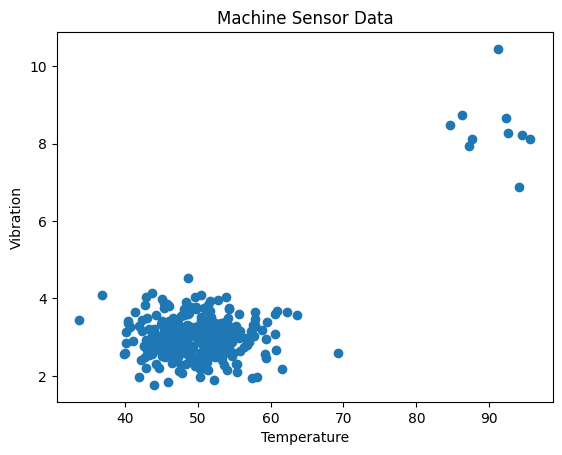

In [17]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Temperature"],
    df["Vibration"]
)

plt.xlabel("Temperature")
plt.ylabel("Vibration")
plt.title("Machine Sensor Data")

plt.show()

In [18]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.03,
    random_state=42
)

model.fit(df)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.03
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [19]:
predictions = model.predict(df)

print(predictions[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [20]:
df["Anomaly"] = predictions

print(df.head())

   Temperature  Vibration  Anomaly
0    52.483571   2.585502        1
1    49.308678   2.719909        1
2    53.238443   3.373647        1
3    57.615149   3.305185        1
4    48.829233   2.989549        1


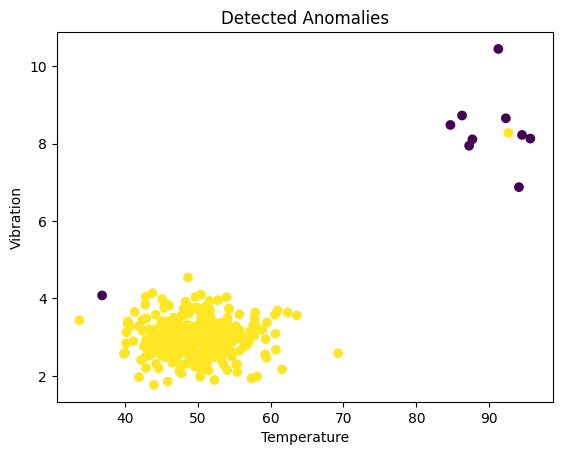

In [21]:
plt.scatter(
    df["Temperature"],
    df["Vibration"],
    c=df["Anomaly"]
)

plt.xlabel("Temperature")
plt.ylabel("Vibration")
plt.title("Detected Anomalies")

plt.show()